In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

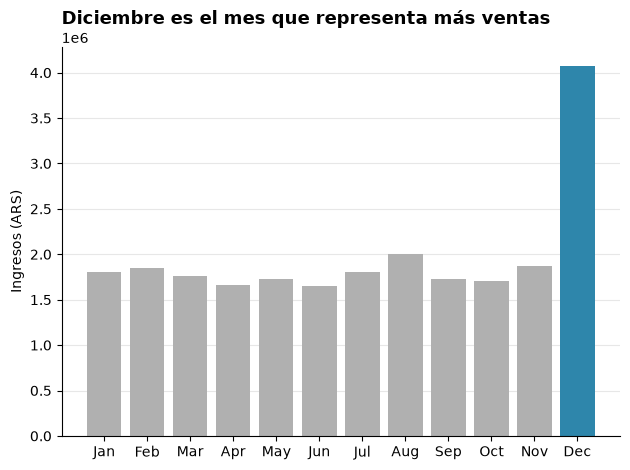

In [5]:
ventas_mensuales = pd.read_csv("ventas_mensuales.csv", parse_dates=["mes"])

fig, ax = plt.subplots()

colores = ["#b0b0b0"] * len (ventas_mensuales)
mes_pico = ventas_mensuales["ingresos"].idxmax()
colores[mes_pico] = "#2e86ab"


ax.bar(ventas_mensuales["mes"].dt.strftime("%b"), ventas_mensuales["ingresos"], color=colores)
ax.set_title ("Diciembre es el mes que representa más ventas", loc="left", fontsize=13, weight="bold")
ax.set_ylabel("Ingresos (ARS)")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Text(0.0, 1.0, 'Diciembre es el mes que representa más ventas')

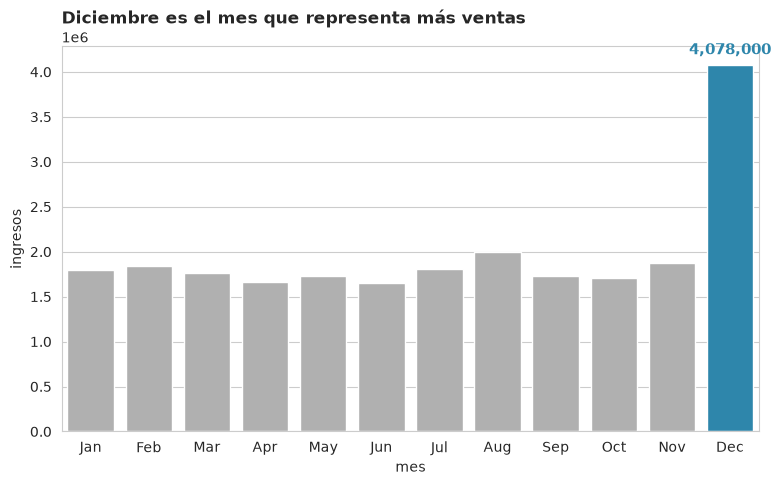

In [14]:
sns.set_style("whitegrid") 

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=ventas_mensuales,
    x=ventas_mensuales["mes"].dt.strftime("%b"),
    y="ingresos",
    color="#B0B0B0",
    ax=ax,
)
ax.patches[mes_pico].set_facecolor("#2E86AB")

# 1. Obtener la geometría de la barra pico para la anotación
p = ax.patches[mes_pico]
x_pos = p.get_x() + p.get_width() / 2
y_pos = p.get_height()

# 2. Agregar la anotación exactamente sobre la barra
ax.annotate(
    f"{y_pos:,.0f}",  # Formato numérico (puedes usar f"${y_pos:,.0f}" si son ingresos con moneda)
    xy=(x_pos, y_pos),
    xytext=(
        0,
        5,
    ),  # Desplaza el texto 5 puntos hacia arriba para que no pegue con la barra
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    color="#2E86AB",
)

ax.set_title("Diciembre es el mes que representa más ventas", loc="left", weight="bold")

In [15]:
ventas_categorias = pd.read_csv("ventas_por_categoria.csv")
print(ventas_categorias)

      categoria  ingresos
0   electronica   9800000
1  indumentaria   4100000
2         hogar   3600000
3      deportes   2900000
4      juguetes   1450000
5        libros    980000


Tenemos 6 categorías. Vamos a elegir el gráfico de barras horizontales porque es más fácil de leer. Como dice el artículo "Un gráfico de torta para comparar seis categorías es casi siempre peor que una barra horizontal ordenada, porque el ojo humano compara longitudes con mucha más facilidad que ángulos."

Text(0.0, 1.0, 'Electrónica es la categoría que más se vende')

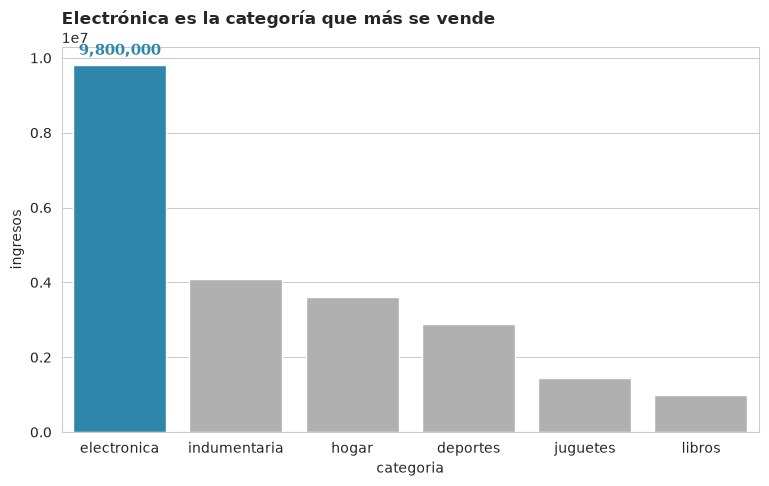

In [25]:
sns.set_style("whitegrid") 

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=ventas_categorias,
    x=ventas_categorias["categoria"],
    y="ingresos",
    color="#B0B0B0",
    ax=ax,
)

colores = ["#b0b0b0"] * len (ventas_categorias)
categoria_pico = ventas_categorias["ingresos"].idxmax()
colores[categoria_pico] = "#2e86ab"

ax.patches[categoria_pico].set_facecolor("#2E86AB")

# 1. Obtener la geometría de la barra pico para la anotación
p = ax.patches[categoria_pico]
x_pos = p.get_x() + p.get_width() / 2
y_pos = p.get_height()

# 2. Agregar la anotación exactamente sobre la barra
ax.annotate(
    f"{y_pos:,.0f}",  # Formato numérico (puedes usar f"${y_pos:,.0f}" si son ingresos con moneda)
    xy=(x_pos, y_pos),
    xytext=(
        0,
        5,
    ),  # Desplaza el texto 5 puntos hacia arriba para que no pegue con la barra
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    color="#2E86AB",
)

ax.set_title("Electrónica es la categoría que más se vende", loc="left", weight="bold")

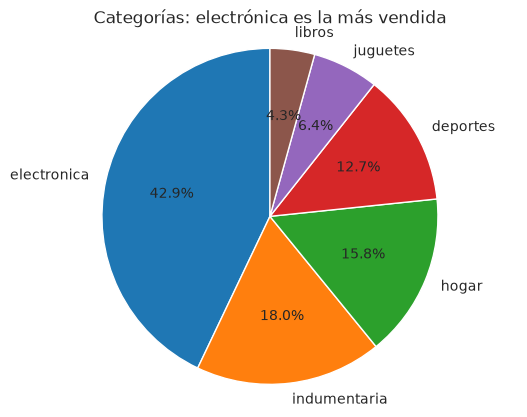

In [29]:
sliceizes = ventas_categorias["ingresos"]
labels = ventas_categorias["categoria"]

fig, ax = plt.subplots()

ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

ax.axis('equal')
ax.set_title("Categorías: electrónica es la más vendida")

plt.show()

    mes  variacion_pct
0   Jan            2.8
1   Feb           -5.4
2   Mar            1.8
3   Apr            7.6
4   May           -8.8
5   Jun           -1.7
6   Jul          -13.2
7   Aug           -8.3
8   Sep          -12.7
9   Oct            0.1
10  Nov           -8.1
11  Dec           18.5
El mes que más se aleja del resto es **Dec** con una variación de **18.5%**.


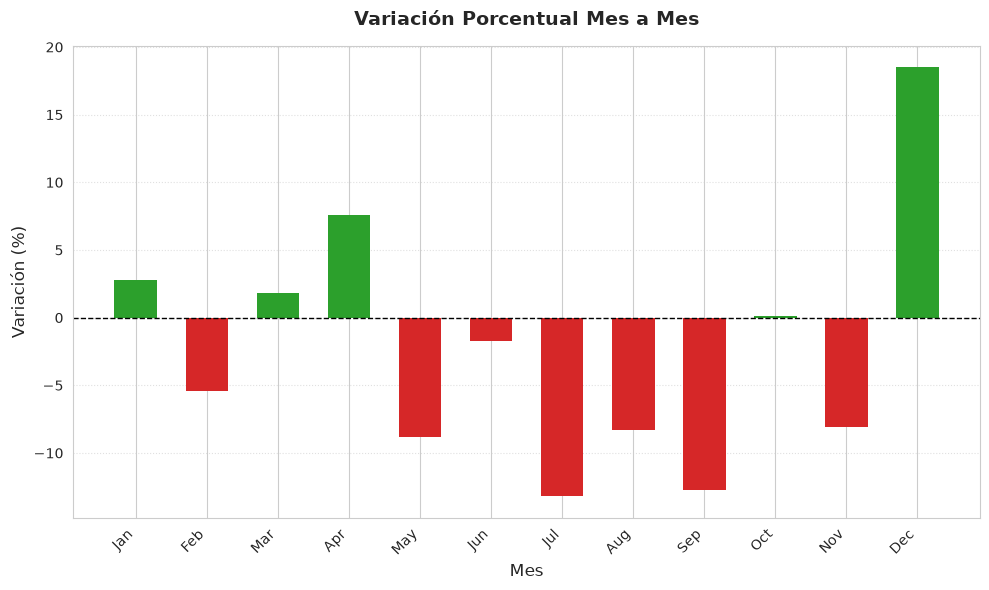

In [40]:
variacion_mensual = pd.read_csv("variacion_mensual.csv")
print(variacion_mensual)

# 2. Definir una paleta divergente según el signo
# Verde para valores positivos y Rojo para negativos
colores = ['#2ca02c' if x >= 0 else '#d62728' for x in variacion_mensual['variacion_pct']]

# 3. Crear la figura y el gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(
    variacion_mensual['mes'], variacion_mensual['variacion_pct'], color=colores, width=0.6, edgecolor='none'
)

# 4. Añadir línea de referencia en cero
ax.axhline(0, color='black', linewidth=1, linestyle='--')

# 5. Personalizar etiquetas, títulos y diseño
ax.set_title(
    'Variación Porcentual Mes a Mes', fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Variación (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# 6. Identificar qué mes se aleja más del resto
# Se busca el valor con mayor magnitud absoluta (el pico más alto o más bajo)
indice_max = variacion_mensual['variacion_pct'].abs().idxmax()
mes_mas_alejado = variacion_mensual.loc[indice_max, 'mes']
valor_mas_alejado = variacion_mensual.loc[indice_max, 'variacion_pct']

print(
    f'El mes que más se aleja del resto es **{mes_mas_alejado}** '
    f'con una variación de **{valor_mas_alejado}%**.'
)

# 7. Mostrar el gráfico
plt.tight_layout()
plt.show()

El mes que más se aleja del resto es **Dec** con una variación de **18.5%**.


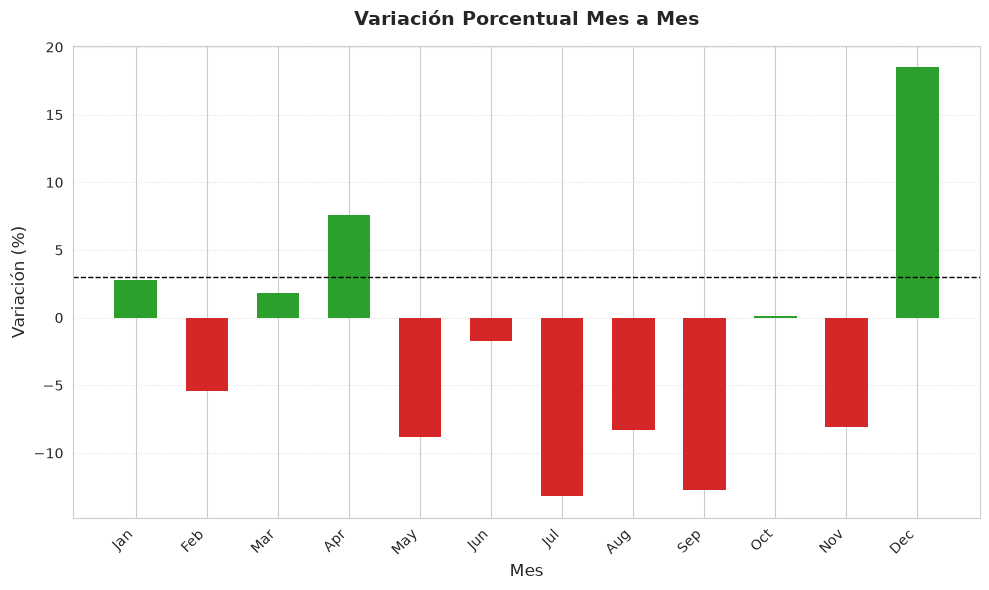

In [41]:
# 2. Definir una paleta divergente según el signo
# Verde para valores positivos y Rojo para negativos
colores = ['#2ca02c' if x >= 0 else '#d62728' for x in variacion_mensual['variacion_pct']]

# 3. Crear la figura y el gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(
    variacion_mensual['mes'], variacion_mensual['variacion_pct'], color=colores, width=0.6, edgecolor='none'
)

# 4. Añadir línea de referencia en cero
ax.axhline(3, color='black', linewidth=1, linestyle='--')

# 5. Personalizar etiquetas, títulos y diseño
ax.set_title(
    'Variación Porcentual Mes a Mes', fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Variación (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# 6. Identificar qué mes se aleja más del resto
# Se busca el valor con mayor magnitud absoluta (el pico más alto o más bajo)
indice_max = variacion_mensual['variacion_pct'].abs().idxmax()
mes_mas_alejado = variacion_mensual.loc[indice_max, 'mes']
valor_mas_alejado = variacion_mensual.loc[indice_max, 'variacion_pct']

print(
    f'El mes que más se aleja del resto es **{mes_mas_alejado}** '
    f'con una variación de **{valor_mas_alejado}%**.'
)

# 7. Mostrar el gráfico
plt.tight_layout()
plt.show()

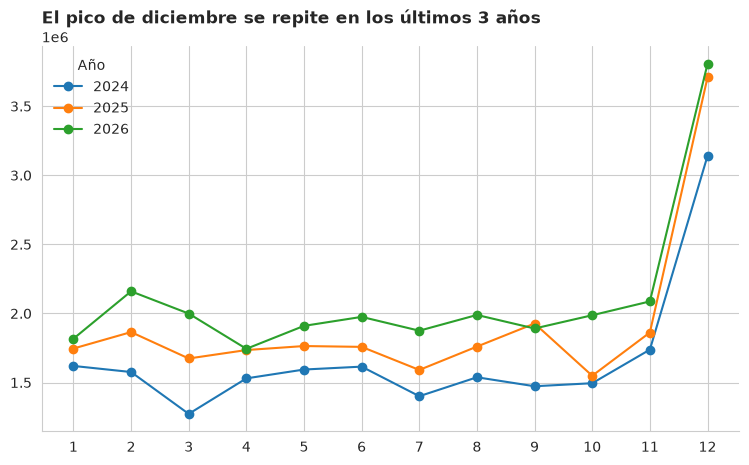

In [43]:
historico = pd.read_csv("ventas_historico_3anios.csv", parse_dates=["mes"])

fig, ax = plt.subplots(figsize=(9, 5))
for anio, grupo in historico.groupby(historico["mes"].dt.year):
    ax.plot(grupo["mes"].dt.month, grupo["ingresos"], marker="o", label=str(anio))

ax.set_title("El pico de diciembre se repite en los últimos 3 años", loc="left", weight="bold")
ax.set_xticks(range(1, 13))
ax.legend(title="Año", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

¿Cuál es el mes en el que se registran menos ventas?
Usemos un gráfico de barras verticales.
Contexto, hallazgo, evidencia, recomendación.
